In [1]:
import torch
import torch.nn as nn
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data_str = urllib.request.urlopen(url).read().decode('utf-8')
raw_data = [float(line.split(',')[1]) for line in data_str.strip().split('\n')[1:]]
data = (np.array(raw_data) - np.mean(raw_data)) / np.std(raw_data)

In [3]:
seq_len = 12
X, y = [], []
for i in range(len(data) - seq_len):
    X.append(data[i:i+seq_len])
    y.append(data[i+seq_len])
X = torch.FloatTensor(X).unsqueeze(-1).to(device)
y = torch.FloatTensor(y).unsqueeze(-1).to(device)

/var/folders/qg/2l8949_j0jdd9374hflg77dr0000gn/T/ipykernel_12491/3228197679.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X = torch.FloatTensor(X).unsqueeze(-1).to(device)


In [4]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 16, batch_first=True)
        self.fc = nn.Linear(16, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [5]:
model = RNNModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses = []
for epoch in range(50):
    optimizer.zero_grad()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

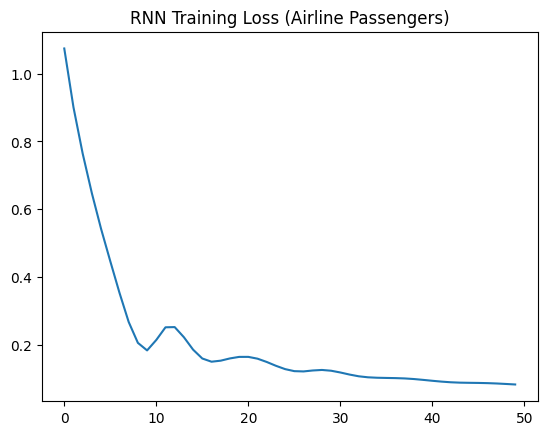

In [6]:
plt.plot(losses)
plt.title('RNN Training Loss (Airline Passengers)')
plt.savefig('rnn_loss.png')